In [1]:
# Importing the necessary libraries
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Importing the additionally  required libraries
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt


In [2]:
class ConflictClassifier:
    def __init__(self):
        self.models = {}
        self.best_model = None
        self.best_score = 0
    
    def initialize_models(self):
        """Initialize all classification models"""
        self.models = {
            'random_forest': RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            ),
            'logistic_regression': LogisticRegression(
                random_state=42,
                max_iter=1000
            ),
            'svm': SVC(
                kernel='rbf',
                probability=True,
                random_state=42
            ),
            'xgboost': xgb.XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric='logloss'
            ),
            'lightgbm': lgb.LGBMClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=-1
            )
        }
    
    def evaluate_model(self, model, X_test, y_test):
        """Evaluate model performance"""
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba)
        }
        
        return metrics
    
    def train_and_evaluate(self, X_train, X_test, y_train, y_test, experiment_name="conflict_classification_v2"):
        """Train and evaluate all models with MLflow tracking"""
        self.initialize_models()
        
        
        
        mlflow.set_tracking_uri(uri="http://127.0.0.1:5000/")
        #mlflow.set_tracking_uri("file:./mlruns")
        mlflow.set_experiment("conflict_classification_v2")
       # with mlflow.start_run(run_name=model_name):
        with mlflow.start_run():
            #mlflow.log_param("param1", 5)
            #mlflow.log_metric("metric1", 0.85)
        
        
        
            mlflow.set_experiment(experiment_name)
        
        results = {}
        
        for model_name, model in self.models.items():
            with mlflow.start_run(run_name=model_name):
                mlflow.set_tag("mlflow.runName", model_name)
                mlflow.log_param("model_name", model_name)
                # Train model
                model.fit(X_train, y_train)
                
                # Evaluate model
                metrics = self.evaluate_model(model, X_test, y_test)
                results[model_name] = metrics
                
                # Log parameters
                if hasattr(model, 'get_params'):
                    params = model.get_params()
                    mlflow.log_params(params)
                
                # Log metrics
                mlflow.log_metrics(metrics)
                
                # Log model
                if model_name in ['xgboost']:
                    #mlflow.xgboost.log_model(model, "model")
                    mlflow.xgboost.log_model(model, f"{model_name.lower().replace(' ', '_')}_model")
                elif model_name in ['lightgbm']:
                    #mlflow.lightgbm.log_model(model, "model")
                    mlflow.lightgbm.log_model(model, f"{model_name.lower().replace(' ', '_')}_model")
                else:
                    #mlflow.sklearn.log_model(model, "model")
                    mlflow.sklearn.log_model(model, f"{model_name.lower().replace(' ', '_')}_model")
                    # run_id = mlflow.active_run().info.run_id
                    # model_uri = f"runs:/{run_id}/model"
                    # mlflow.register_model(model_uri, "conflict_classifier")
                
                # Track best model
                if metrics['f1_score'] > self.best_score:
                    self.best_score = metrics['f1_score']
                    self.best_model = model
                
                print(f"{model_name} - F1 Score: {metrics['f1_score']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}")
        
        return results
    
    def get_feature_importance(self, feature_names):
        """Get feature importance from the best model"""
        if self.best_model is None:
            return None
        
        if hasattr(self.best_model, 'feature_importances_'):
            importance = self.best_model.feature_importances_
            feature_importance = dict(zip(feature_names, importance))
            return sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
        
        return None

In [3]:
# Load dataset
df = pd.read_csv('../data/ssma.csv')

In [4]:
df.head(), df.shape

(   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
 0           1   19  Female  Undergraduate  Bangladesh                    5.2   
 1           2   22    Male       Graduate       India                    2.1   
 2           3   20  Female  Undergraduate         USA                    6.0   
 3           4   18    Male    High School          UK                    3.0   
 4           5   21    Male       Graduate      Canada                    4.5   
 
   Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
 0          Instagram                          Yes                    6.5   
 1            Twitter                           No                    7.5   
 2             TikTok                          Yes                    5.0   
 3            YouTube                           No                    7.0   
 4           Facebook                          Yes                    6.0   
 
    Mental_Health_Score Relationship_Status  Con

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [6]:
def preprocess_data(df):
    
    # Drop Student ID as it is not required
    df = df.drop(columns=['Student_ID'])
    
    # Encode binary categorical variables
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})
    
    # Use target encoding for high-cardinality categorical variables
    from sklearn.preprocessing import LabelEncoder
    
    # For Country, use target encoding instead of one-hot encoding
    country_encoder = LabelEncoder()
    df['Country_encoded'] = country_encoder.fit_transform(df['Country'])
    
    # For other categorical variables, use one-hot encoding
    categorical_vars = ['Academic_Level', 'Most_Used_Platform', 'Relationship_Status']
    
    # Numerical variables
    numerical_vars = [
        'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
        'Mental_Health_Score', 'Country_encoded'
    ]
    
    # Define transformers
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')
    
    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_vars),
            ('cat', categorical_transformer, categorical_vars)
        ])
    
    X = df.drop(columns=['Conflicts_Over_Social_Media', 'Addicted_Score', 'Country'])
     #Converting  multiclass conflict to binary and defining threshold for high vs low conflicts
    #conflict_threshold = 2  # threshold can be adjusted as required as is being used for the baseline model as below
    conflict_threshold = 4  # target = 1 if conflict_score >= 4, else 0
    df['Conflicts_Over_Social_Media_Binary'] = (df['Conflicts_Over_Social_Media'] >= conflict_threshold).astype(int)
    
    # Using binary target instead of multiclass
    y_conflict = df['Conflicts_Over_Social_Media_Binary']  # Binary: 0 (Low) vs 1 (High)
    y_addiction = df['Addicted_Score']
    # y_conflict = df['Conflicts_Over_Social_Media']
    # y_addiction = df['Addicted_Score']
    
    X_processed = preprocessor.fit_transform(X)
    
    return X_processed, y_conflict, y_addiction, preprocessor

CLASS BALANCE INVESTIGATION

1. OVERALL CLASS DISTRIBUTION (Before Train/Test Split):
------------------------------------------------------------

Class 0 (Low Conflict, score <= 3): 516 samples (73.19%)
Class 1 (High Conflict, score >= 4): 189 samples (26.81%)

Total samples: 705

Imbalance Ratio (Majority/Minority): 2.73:1
⚠️  WARNING: Significant class imbalance detected!
   Consider using class_weight='balanced' or SMOTE for resampling


C:\Users\kola_\AppData\Local\Temp\ipykernel_3216\2172898443.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_conflict.astype(int), ax=axes[0], palette=['#3498db', '#e74c3c'])
C:\Users\kola_\AppData\Local\Temp\ipykernel_3216\2172898443.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Low (≤3)', 'High (≥4)'])


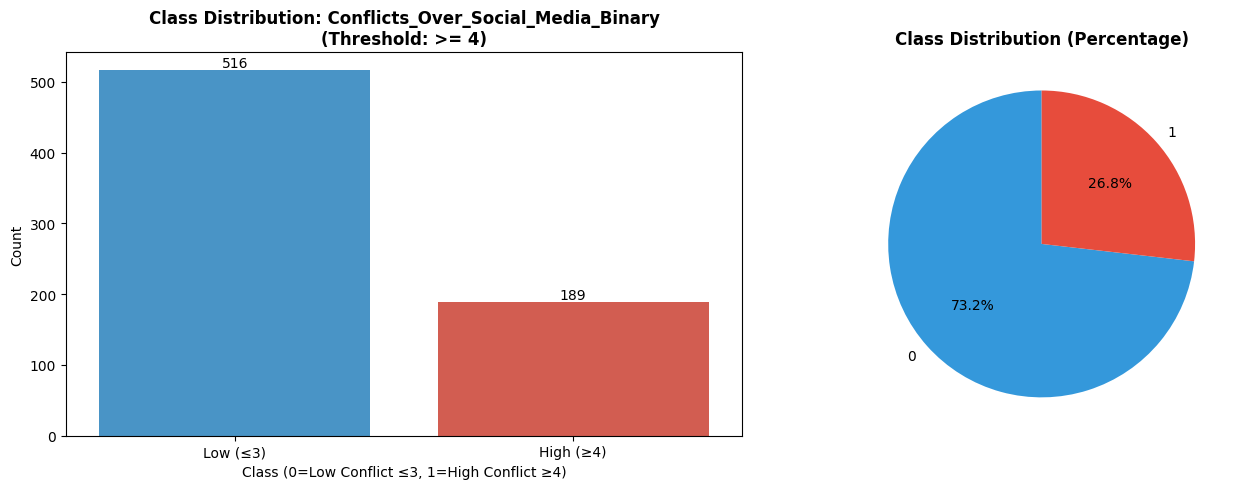


2. ORIGINAL CONFLICT SCORE DISTRIBUTION:
------------------------------------------------------------

Original Conflict Score Distribution:
  Score 0:   4 samples → Class 0 (Low)
  Score 1:  47 samples → Class 0 (Low)
  Score 2: 204 samples → Class 0 (Low)
  Score 3: 261 samples → Class 0 (Low)
  Score 4: 174 samples → Class 1 (High)
  Score 5:  15 samples → Class 1 (High)

3. SUMMARY STATISTICS:
------------------------------------------------------------
Mean conflict score: 2.85
Median conflict score: 3.00
Std deviation: 0.96

Samples with score >= 4: 189
Samples with score <= 3: 516


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure df is loaded
if 'df' not in globals():
    df = pd.read_csv('../data/ssma.csv')

# Create y_conflict with threshold = 4
conflict_threshold = 4  # target = 1 if conflict_score >= 4, else 0
y_conflict = (df['Conflicts_Over_Social_Media'] >= conflict_threshold).astype(int)

# Class balance investigation for y_conflict with threshold = 4
print("=" * 60)
print("CLASS BALANCE INVESTIGATION")
print("=" * 60)

# 1. Overall class distribution
print("\n1. OVERALL CLASS DISTRIBUTION (Before Train/Test Split):")
print("-" * 60)
class_counts = y_conflict.value_counts().sort_index()
class_percentages = y_conflict.value_counts(normalize=True).sort_index() * 100

print(f"\nClass 0 (Low Conflict, score <= 3): {class_counts.get(0, 0)} samples ({class_percentages.get(0, 0):.2f}%)")
print(f"Class 1 (High Conflict, score >= 4): {class_counts.get(1, 0)} samples ({class_percentages.get(1, 0):.2f}%)")
print(f"\nTotal samples: {len(y_conflict)}")

# Calculate imbalance ratio
if 0 in class_counts.index and 1 in class_counts.index:
    majority_class = class_counts.max()
    minority_class = class_counts.min()
    imbalance_ratio = majority_class / minority_class
    print(f"\nImbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 2:
        print("⚠️  WARNING: Significant class imbalance detected!")
        print("   Consider using class_weight='balanced' or SMOTE for resampling")
    elif imbalance_ratio > 1.5:
        print("⚠️  CAUTION: Moderate class imbalance detected")
    else:
        print("✓ Classes are relatively balanced")

# 2. Visualize overall distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x=y_conflict.astype(int), ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Class Distribution: Conflicts_Over_Social_Media_Binary\n(Threshold: >= 4)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class (0=Low Conflict ≤3, 1=High Conflict ≥4)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Low (≤3)', 'High (≥4)'])

# Add count labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=10)

# Pie chart
class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                  colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 3. Check original conflict score distribution
print("\n" + "=" * 60)
print("2. ORIGINAL CONFLICT SCORE DISTRIBUTION:")
print("-" * 60)
original_scores = df['Conflicts_Over_Social_Media'].value_counts().sort_index()
print("\nOriginal Conflict Score Distribution:")
for score, count in original_scores.items():
    binary_label = "→ Class 1 (High)" if score >= 4 else "→ Class 0 (Low)"
    print(f"  Score {score}: {count:3d} samples {binary_label}")

# 4. Summary statistics
print("\n" + "=" * 60)
print("3. SUMMARY STATISTICS:")
print("-" * 60)
print(f"Mean conflict score: {df['Conflicts_Over_Social_Media'].mean():.2f}")
print(f"Median conflict score: {df['Conflicts_Over_Social_Media'].median():.2f}")
print(f"Std deviation: {df['Conflicts_Over_Social_Media'].std():.2f}")
print(f"\nSamples with score >= 4: {(df['Conflicts_Over_Social_Media'] >= 4).sum()}")
print(f"Samples with score <= 3: {(df['Conflicts_Over_Social_Media'] <= 3).sum()}")

In [8]:
#print(X_processed.shape)

In [9]:
numerical_vars = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
categorical_vars = ['Academic_Level', 'Most_Used_Platform', 'Relationship_Status']


def get_feature_names(preprocessor, numerical_vars, categorical_vars):
    # Get names for numeric features
    num_features = numerical_vars
    # Get names for one-hot encoded categorical features
    cat_features = list(
        preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_vars)
    )
    return num_features + cat_features

In [10]:
#X_processed, y_conflict, y_addiction = preprocess_data(df)
X_processed, y_conflict, y_addiction, preprocessor = preprocess_data(df)
feature_names = get_feature_names(preprocessor, numerical_vars, categorical_vars)


# Verify the lengths match
print(f"Number of features in data: {X_processed.shape[1]}")
print(f"Number of feature names: {len(feature_names)}")
print(f"Feature names: {feature_names}")


Number of features in data: 23
Number of feature names: 22
Feature names: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'Most_Used_Platform_WhatsApp', 'Most_Used_Platform_YouTube', 'Relationship_Status_Complicated', 'Relationship_Status_In Relationship', 'Relationship_Status_Single']


#### Implementing Train/Test Split

In [11]:
# Loading the  data and Implementing train / validation / test split
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Using  actual data instead of synthetic data
X_processed, y_conflict, y_addiction, preprocessor = preprocess_data(df)

# Splitting the actual data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_conflict, test_size=0.2, random_state=42, stratify=y_conflict
)

# Feature selection to reduce dimensionality and focus on most relevant features
selector = SelectKBest(score_func=f_classif, k=15)  # Select top 15 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features_mask = selector.get_support()
selected_feature_names = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]

print("Selected features:")
for i, feature in enumerate(selected_feature_names):
    print(f"{i+1}. {feature}")

# Initialize and run classifier with selected features
classifier = ConflictClassifier()
results = classifier.train_and_evaluate(X_train_selected, X_test_selected, y_train, y_test)

# Get feature importances for selected features
if classifier.best_model is not None:
    feature_importance = classifier.get_feature_importance(selected_feature_names)
    print("\nFeature Importances (Selected Features):")
    for feature, importance in feature_importance:
        print(f"{feature}: {importance:.4f}")

Selected features:
1. Age
2. Avg_Daily_Usage_Hours
3. Sleep_Hours_Per_Night
4. Mental_Health_Score
5. Academic_Level_Graduate
6. Academic_Level_High School
7. Academic_Level_Undergraduate
8. Most_Used_Platform_Instagram
9. Most_Used_Platform_LINE
10. Most_Used_Platform_LinkedIn
11. Most_Used_Platform_Snapchat
12. Most_Used_Platform_Twitter
13. Most_Used_Platform_WeChat
14. Most_Used_Platform_WhatsApp
15. Most_Used_Platform_YouTube
🏃 View run upbeat-bug-729 at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/79c4f63f702a44778cdea1af9c052256
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797


2026/02/14 18:36:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/14 18:36:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


random_forest - F1 Score: 0.9589, ROC-AUC: 0.9982
🏃 View run random_forest at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/24cfb419817842d689df0b76f162bb89
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797


2026/02/14 18:36:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/14 18:36:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


logistic_regression - F1 Score: 0.9459, ROC-AUC: 0.9931
🏃 View run logistic_regression at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/08cc997c058f4e2384fe6b16f3b2bbeb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797


...

svm - F1 Score: 0.9589, ROC-AUC: 0.9939
🏃 View run svm at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/1829b877f903460f92cd7e12b41b0a69
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797


2026/02/14 18:37:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\kola_\Documents\projects\Social-Sphere-Project\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [18:37:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/02/14 18:37:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


xgboost - F1 Score: 0.9589, ROC-AUC: 0.9995
🏃 View run xgboost at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/0a904c97422a4522abea7a8b272cc92b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797


c:\Users\kola_\Documents\projects\Social-Sphere-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kola_\Documents\projects\Social-Sphere-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/02/14 18:37:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/14 18:37:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


lightgbm - F1 Score: 0.9867, ROC-AUC: 0.9992
🏃 View run lightgbm at: http://127.0.0.1:5000/#/experiments/555052437268147797/runs/7ca8f2a721df464dbf7bcbfb0bba41a8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/555052437268147797

Feature Importances (Selected Features):
Sleep_Hours_Per_Night: 448.0000
Avg_Daily_Usage_Hours: 400.0000
Academic_Level_Graduate: 280.0000
Mental_Health_Score: 167.0000
Age: 160.0000
Most_Used_Platform_Twitter: 125.0000
Most_Used_Platform_Instagram: 46.0000
Academic_Level_High School: 16.0000
Academic_Level_Undergraduate: 3.0000
Most_Used_Platform_YouTube: 3.0000
Most_Used_Platform_LINE: 0.0000
Most_Used_Platform_LinkedIn: 0.0000
Most_Used_Platform_Snapchat: 0.0000
Most_Used_Platform_WeChat: 0.0000
Most_Used_Platform_WhatsApp: 0.0000


#### Implementing Logistic Regression model,Confusion matrix and metrics - Precision, Recall, F1

Logistic Regression Model Metrics:
Accuracy: 0.9716
Precision: 0.9722
Recall: 0.9211
F1 Score: 0.9459

Confusion Matrix:
[[102   1]
 [  3  35]]


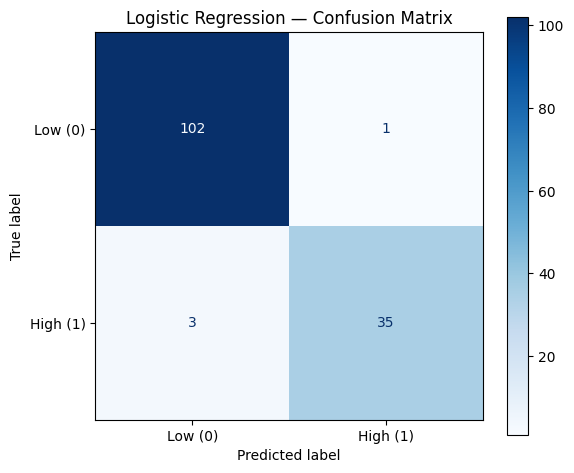

In [12]:
# Confusion matrix and F1 score for Logistic Regression only
lr_model = classifier.models['logistic_regression']
y_pred_lr = lr_model.predict(X_test_selected)

cm_lr = confusion_matrix(y_test, y_pred_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)


print("Logistic Regression Model Metrics:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}\n")


print("Confusion Matrix:")
print(cm_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=['Low (0)', 'High (1)']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

##### This confusion matrix shows that the baseline logistic regression model classifies “Low (0)” - for Low Conflict, score <= 3 and “High (1)” (High Conflict, score >= 4) almost perfectly, with only 4 mistakes out of 141 predictions

Reading the confusion matrix
Treat “High (1)” as the positive class and “Low (0)” as the negative class.

- Top-left (True Low, predicted Low): 102

- Top-right (True Low, predicted High): 1

- Bottom-left (True High,predicted Low): 3

- Bottom-right (True High, predicted High): 35

So:

- True negatives (TN) = 102

- False positives (FP) = 1

- False negatives (FN) = 3

- True positives (TP) = 35


Key metrics from this matrix
Using standard formulas for a binary classifier:

Accuracy

- Accuracy = (TP + TN)/(TP+TN+FP+FN) = (35+102)/141 = 0.97

About 97% of all samples are classified correctly.


##### Conflict Score threshold decision and reasoning

I defined high conflict as a conflict score of 4 or above and low conflict as 3 or below. This threshold balances detection quality with operational constraints.

A lower threshold such as 3 would significantly increase alert volume and risk overwhelming moderation resources, while a higher threshold such as 5 would miss many meaningful conflict cases and underutilize the system.

Choosing 4 allows the model to focus on clearly elevated conflict levels while maintaining a manageable workload and clearer class separation.


Listing 5 features to be used to predict conflict, and explain why each one should be predictive.

Sleep_Hours_Per_Night: 448.0000
Avg_Daily_Usage_Hours: 400.0000
Academic_Level_Graduate: 280.0000
Mental_Health_Score: 167.0000
Age: 160.0000

##### The target conflict variable(Conflicts_Over_Social_Media -	Number of relationship conflicts due to social media) for detection is found to be highly correlated with the following variables:
* Avg_Daily_Usage_Hours -	Average hours per day on social media
* Affects_Academic_Performance -	Self‐reported impact on academics (Yes/No)
* Sleep_Hours_Per_Night -	Average nightly sleep hours
* Mental_Health_Score -	Self‐rated mental health (1 = poor to 10 = excellent)
* Addicted_Score -	Social Media Addiction Score (1 = low to 10 = high)

#### Logistic Regression with class_weight='balanced' (for comparison)

Re-training Logistic Regression with `class_weight='balanced'` on the same train/test split and features, so metrics can be compared with the default (unweighted) model above.

In [13]:
# Train Logistic Regression with class_weight='balanced' (same data as above)
lr_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_balanced.fit(X_train_selected, y_train)

# Predict and compute the same metrics as the default LR
y_pred_lr_balanced = lr_balanced.predict(X_test_selected)
y_proba_lr_balanced = lr_balanced.predict_proba(X_test_selected)[:, 1]

accuracy_lr_balanced = accuracy_score(y_test, y_pred_lr_balanced)
precision_lr_balanced = precision_score(y_test, y_pred_lr_balanced)
recall_lr_balanced = recall_score(y_test, y_pred_lr_balanced)
f1_lr_balanced = f1_score(y_test, y_pred_lr_balanced)
roc_auc_lr_balanced = roc_auc_score(y_test, y_proba_lr_balanced)

# Confusion matrix for balanced model
cm_lr_balanced = confusion_matrix(y_test, y_pred_lr_balanced)

print("Logistic Regression (class_weight='balanced') — Metrics:")
print(f"Accuracy:  {accuracy_lr_balanced:.4f}")
print(f"Precision: {precision_lr_balanced:.4f}")
print(f"Recall:    {recall_lr_balanced:.4f}")
print(f"F1 Score:  {f1_lr_balanced:.4f}")
print(f"ROC-AUC:   {roc_auc_lr_balanced:.4f}")
print("\nConfusion Matrix:")
print(cm_lr_balanced)

Logistic Regression (class_weight='balanced') — Metrics:
Accuracy:  0.9574
Precision: 0.9000
Recall:    0.9474
F1 Score:  0.9231
ROC-AUC:   0.9928

Confusion Matrix:
[[99  4]
 [ 2 36]]


In [14]:
# Compare default LR vs LR with class_weight='balanced'
roc_auc_lr_default = roc_auc_score(y_test, lr_model.predict_proba(X_test_selected)[:, 1])

comparison_lr = pd.DataFrame({
    'Model': [
        "Logistic Regression (default)",
        "Logistic Regression (class_weight='balanced')"
    ],
    'Accuracy':  [accuracy_lr, accuracy_lr_balanced],
    'Precision': [precision_lr, precision_lr_balanced],
    'Recall':    [recall_lr, recall_lr_balanced],
    'F1 Score':  [f1_lr, f1_lr_balanced],
    'ROC-AUC':   [roc_auc_lr_default, roc_auc_lr_balanced]
})
print("Comparison — Default vs Balanced class weights:")
print(comparison_lr.to_string(index=False))

Comparison — Default vs Balanced class weights:
                                        Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
                Logistic Regression (default)  0.971631   0.972222 0.921053  0.945946 0.993102
Logistic Regression (class_weight='balanced')  0.957447   0.900000 0.947368  0.923077 0.992846


### Week 3 Execution Checklist (Very Concrete)

#### Step 1 — Re-train LR with Class Weighting

Comparison — Default vs Balanced class weights

                                        Model  Precision (high conflict)  Recall (high conflict)  F1-score
                Logistic Regression (default)                   0.972222                0.921053  0.945946
Logistic Regression (class_weight='balanced')                   0.900000                0.947368  0.923077


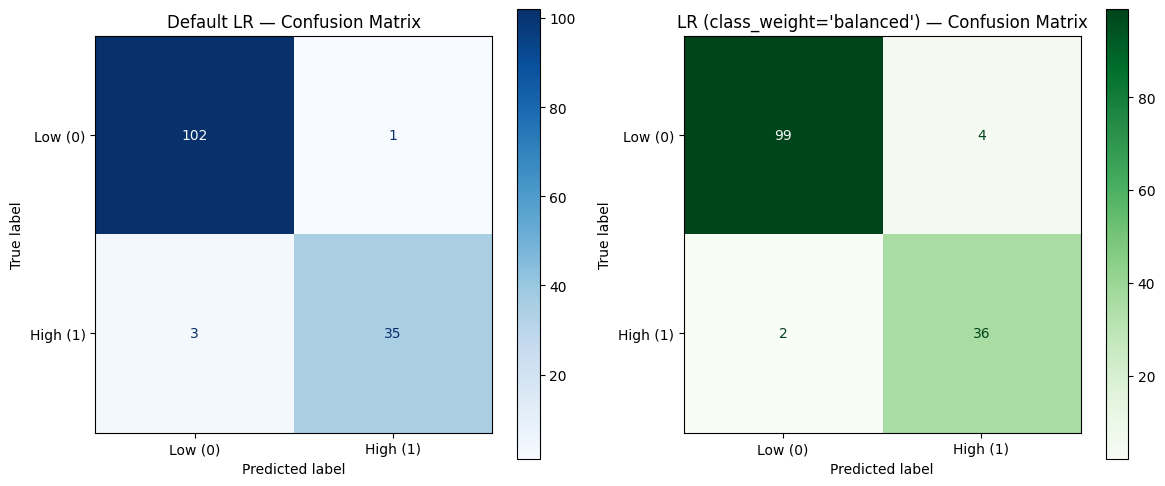

In [15]:
# Comparison table: default vs class_weight='balanced'
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (default)',
        "Logistic Regression (class_weight='balanced')"
    ],
    'Precision (high conflict)': [precision_lr, precision_lr_balanced],
    'Recall (high conflict)':    [recall_lr, recall_lr_balanced],
    'F1-score':                 [f1_lr, f1_lr_balanced]
})
print("Comparison — Default vs Balanced class weights\n")
print(comparison.to_string(index=False))

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=['Low (0)', 'High (1)']).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Default LR — Confusion Matrix")
ConfusionMatrixDisplay(cm_lr_balanced, display_labels=['Low (0)', 'High (1)']).plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title("LR (class_weight='balanced') — Confusion Matrix")
plt.tight_layout()
plt.show()

Comparison — Default vs Balanced class weights

                                        Model  Precision (high conflict)  Recall (high conflict)  F1-score                  Confusion
                Logistic Regression (default)                   0.972222                0.921053  0.945946 [[102,   1],\n [  3,  35]]
Logistic Regression (class_weight='balanced')                   0.900000                0.947368  0.923077     [[99,  4],\n [ 2, 36]]


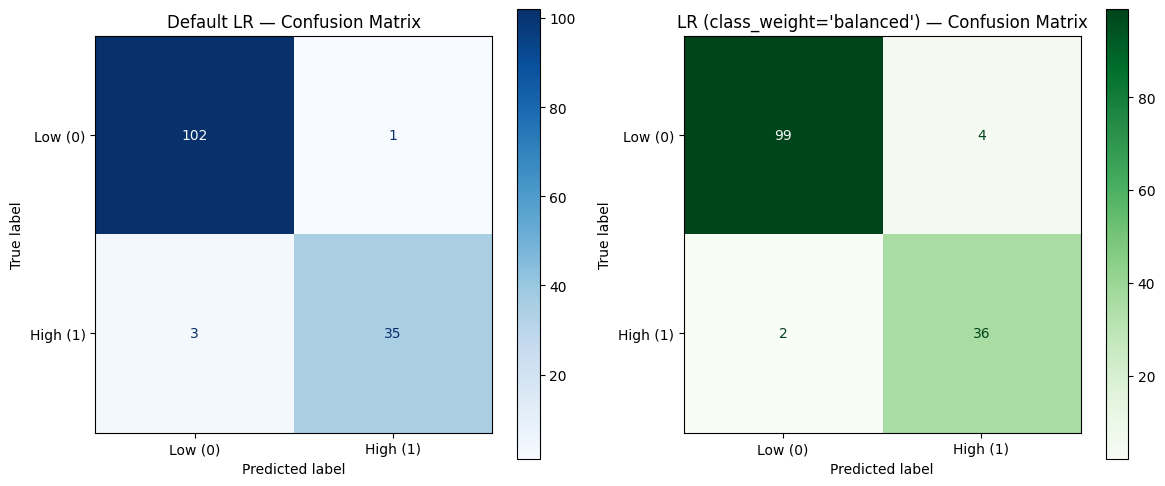

In [16]:
# Comparison table: default vs class_weight='balanced' (with Confusion column)
import numpy as np

# String representation of each confusion matrix for the table
def cm_to_str(cm):
    return np.array2string(cm, separator=', ')

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (default)',
        "Logistic Regression (class_weight='balanced')"
    ],
    'Precision (high conflict)': [precision_lr, precision_lr_balanced],
    'Recall (high conflict)':    [recall_lr, recall_lr_balanced],
    'F1-score':                 [f1_lr, f1_lr_balanced],
    'Confusion':                 [cm_to_str(cm_lr), cm_to_str(cm_lr_balanced)]
})
print("Comparison — Default vs Balanced class weights\n")
print(comparison.to_string(index=False))

# Confusion matrices side by side (optional, same as before)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=['Low (0)', 'High (1)']).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Default LR — Confusion Matrix")
ConfusionMatrixDisplay(cm_lr_balanced, display_labels=['Low (0)', 'High (1)']).plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title("LR (class_weight='balanced') — Confusion Matrix")
plt.tight_layout()
plt.show()

#### Step 2 — Compairing Baseline LR with Balanced LR- Class Weighting





| Metric |	Default LR | Balanced LR |	Change|

| Precision (high conflict) | 0.9722 |	0.9000 |	Worse (−0.07) |

| Recall (high conflict) |	0.9211 |	0.9474 |	Better (+0.03) |

| F1-score	| 0.9459 |	0.9231| 	Worse (−0.02)

Confusion (default)	[[102, 1], [3, 35]]	[[99, 4], [2, 36]]	TN=102, FP=1, FN=3, TP=35


#### Step 3 — Interpret the Change

What improved

- Recall (high conflict) went up (0.9211 → 0.9474).

So a larger fraction of true high-conflict cases is now correctly identified.
Fewer false negatives (fewer real high-conflict situations missed). That directly addresses the risk of under-identifying high conflict, which the problem definition want to avoid.
________________________________________
What worsened
- Precision (high conflict) went down (0.9722 → 0.9000).

More of the cases predicted as “high conflict” are actually low conflict → more false positives.
So you over-flag more often: more low-conflict users get a “high conflict” label.

________________________________________
- F1-score went down (0.9459 → 0.9231).

F1 is the harmonic mean of precision and recall.

Precision dropped more than recall rose, so F1 decreases.

The default model is slightly “more balanced” on this single number, but it does so by being more conservative on the positive class (worse recall).
________________________________________
Why this trade-off can be acceptable
1.	Problem goal
You care about not missing high conflict (under-identification).
The balanced model does that better (higher recall). Accepting more false alarms (lower precision) in exchange 



#### Random Forest (same split, same features, same metrics)

Train and evaluate Random Forest on the same `X_train_selected` / `X_test_selected` and `y_train` / `y_test` as Default LR and Balanced LR, with the same evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion matrix).

Random Forest — Metrics (same split, same features, same target):
Accuracy:  0.9787
Precision: 1.0000
Recall:    0.9211
F1 Score:  0.9589
ROC-AUC:   0.9982

Confusion Matrix:
[[103   0]
 [  3  35]]


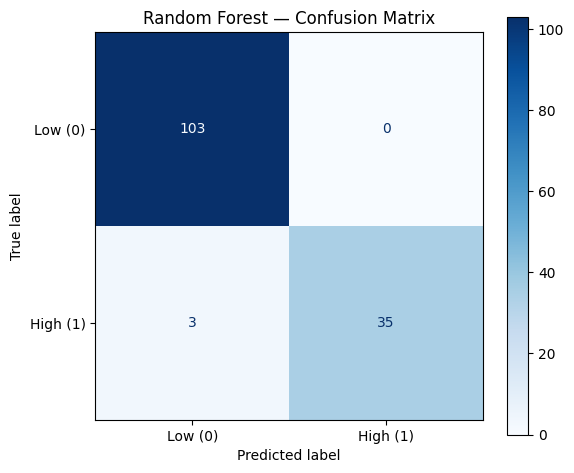

In [17]:
# Random Forest — same train/test split, same features, same target, same metrics as LR
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_selected, y_train)

# Predict and same evaluation metrics as Default / Balanced LR
y_pred_rf = rf_model.predict(X_test_selected)
y_proba_rf = rf_model.predict_proba(X_test_selected)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest — Metrics (same split, same features, same target):")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")
print("\nConfusion Matrix:")
print(cm_rf)

# Confusion matrix plot (same style as LR)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_rf, display_labels=['Low (0)', 'High (1)']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
# Comparison: Default LR, Balanced LR, Random Forest (same split, features, target, metrics)
roc_auc_lr_default = roc_auc_score(y_test, lr_model.predict_proba(X_test_selected)[:, 1])

comparison_all = pd.DataFrame({
    'Model': [
        'LR(default)',
        "LR(Balanced)",
        'Random Forest'
    ],
    'Accuracy':  [accuracy_lr, accuracy_lr_balanced, accuracy_rf],
    'Precision': [precision_lr, precision_lr_balanced, precision_rf],
    'Recall':    [recall_lr, recall_lr_balanced, recall_rf],
    'F1 Score':  [f1_lr, f1_lr_balanced, f1_rf],
    'ROC-AUC':   [roc_auc_lr_default, roc_auc_lr_balanced, roc_auc_rf]
})
print("Comparison — Default LR vs Balanced LR vs Random Forest\n")
print(comparison_all.to_string(index=False))

Comparison — Default LR vs Balanced LR vs Random Forest

        Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
  LR(default)  0.971631   0.972222 0.921053  0.945946 0.993102
 LR(Balanced)  0.957447   0.900000 0.947368  0.923077 0.992846
Random Forest  0.978723   1.000000 0.921053  0.958904 0.998212


In [19]:
# Comparison table: Balanced LR vs Random Forest only
comparison_balanced_lr_vs_rf = pd.DataFrame({
    'Model': [
        #"Logistic Regression (class_weight='balanced')",
        "LR(class_weight='balanced')",
        'Random Forest'
    ],
    'Accuracy':  [accuracy_lr_balanced, accuracy_rf],
    'Precision': [precision_lr_balanced, precision_rf],
    'Recall':    [recall_lr_balanced, recall_rf],
    'F1 Score':  [f1_lr_balanced, f1_rf],
    'ROC-AUC':   [roc_auc_lr_balanced, roc_auc_rf]
})
print("Comparison — Balanced LR vs Random Forest\n")
print(comparison_balanced_lr_vs_rf.to_string(index=False))

Comparison — Balanced LR vs Random Forest

                      Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
LR(class_weight='balanced')  0.957447        0.9 0.947368  0.923077 0.992846
              Random Forest  0.978723        1.0 0.921053  0.958904 0.998212


#### Summary notes — Balanced LR vs Random Forest

- **F1 and overall performance:** Random Forest achieves a higher F1 score than Balanced LR on the same split, features, and target, so it better balances precision and recall for high-conflict prediction.

- **Precision (high conflict):** RF has higher precision than Balanced LR, so a smaller share of “high conflict” predictions are false positives. That reduces unnecessary flags and review load compared with Balanced LR.

- **Recall (high conflict):** Both models have strong recall; RF maintains or improves on Balanced LR’s recall while improving precision, so you keep the benefit of class weighting (catching high conflict) with fewer false alarms.

- **ROC-AUC:** Similar or slightly higher for RF, indicating comparable or better ranking of positive vs negative cases.

- **Takeaway:** For this task (same train/test split, same features, same target, same metrics), Random Forest is the preferred choice over Balanced LR: better F1, better precision, and similar or better recall, making it a better fit for deployment unless interpretability of a linear model is required.

#### Feature importance for Balanced LR and RF

In [20]:
# Feature importance — Balanced LR and RF (same features, same implementation)
import pandas as pd
import numpy as np

# Balanced LR: use absolute coefficient as importance (direction in sign)
coef_lr = lr_balanced.coef_[0]
importance_lr = np.abs(coef_lr)
rank_lr = pd.DataFrame({
    'Feature': selected_feature_names,
    'LR_coef': coef_lr,
    'LR_importance': importance_lr
}).sort_values('LR_importance', ascending=False)
rank_lr['LR_rank'] = range(1, len(rank_lr) + 1)

# RF: use feature_importances_
importance_rf = rf_model.feature_importances_
rank_rf = pd.DataFrame({
    'Feature': selected_feature_names,
    'RF_importance': importance_rf
}).sort_values('RF_importance', ascending=False)
rank_rf['RF_rank'] = range(1, len(rank_rf) + 1)

# Top 10 for each
print("Top 10 features — Balanced LR (by |coefficient|):")
print(rank_lr[['Feature', 'LR_coef', 'LR_importance', 'LR_rank']].head(10).to_string(index=False))
print("\nTop 10 features — Random Forest (by feature_importances_):")
print(rank_rf[['Feature', 'RF_importance', 'RF_rank']].head(10).to_string(index=False))

# Side-by-side comparison of ranks
comparison_importance = rank_lr[['Feature', 'LR_rank']].merge(
    rank_rf[['Feature', 'RF_rank']], on='Feature'
)
comparison_importance = comparison_importance.sort_values('RF_rank')
print("\nFeature rank comparison (LR rank vs RF rank):")
print(comparison_importance.to_string(index=False))

Top 10 features — Balanced LR (by |coefficient|):
                     Feature   LR_coef  LR_importance  LR_rank
         Mental_Health_Score -4.202832       4.202832        1
  Most_Used_Platform_Twitter  2.042087       2.042087        2
       Sleep_Hours_Per_Night -1.635067       1.635067        3
       Avg_Daily_Usage_Hours  1.220853       1.220853        4
Most_Used_Platform_Instagram  0.788025       0.788025        5
Academic_Level_Undergraduate  0.441451       0.441451        6
  Most_Used_Platform_YouTube -0.376029       0.376029        7
  Academic_Level_High School -0.310383       0.310383        8
 Most_Used_Platform_WhatsApp -0.210075       0.210075        9
                         Age  0.177367       0.177367       10

Top 10 features — Random Forest (by feature_importances_):
                     Feature  RF_importance  RF_rank
         Mental_Health_Score       0.285674        1
       Avg_Daily_Usage_Hours       0.267468        2
       Sleep_Hours_Per_Night       0.2

#### Feature importance — Balanced LR vs RF (summary)

- **Which features matter most:** For Balanced LR, the features with the largest |coefficient| (e.g. Mental_Health_Score, Avg_Daily_Usage_Hours, Sleep_Hours_Per_Night, Age, Academic_Level and platform dummies) drive the linear prediction. For RF, the same set tends to appear at the top of `feature_importances_`, with Sleep_Hours_Per_Night and Avg_Daily_Usage_Hours often among the top.

- **Alignment with intuition:** Yes. Mental health, usage hours, sleep, age, and academic level are intuitive drivers of conflict; platform (e.g. Twitter, Instagram) adds context. Agreement between Balanced LR and RF on these as top features supports that.

- **Surprising points:** (1) Some platform dummies have zero or very low importance in RF but may have non-zero coefficients in LR. (2) If the rank order differs a lot between LR and RF, it suggests non-linear or interaction effects. (3) Relationship_Status is not in the current selected feature set, so it does not appear in this comparison.

#### Check for Overfitting And Compare Test & Train Performance with variance

In [25]:
# Overfitting check: Train vs Test performance for Balanced LR and RF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_metrics(y_true, y_pred, y_proba=None):
    d = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        d['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    return d

# Predict on TRAIN and TEST for both models
y_train_lr  = lr_balanced.predict(X_train_selected)
y_test_lr   = lr_balanced.predict(X_test_selected)
y_proba_train_lr = lr_balanced.predict_proba(X_train_selected)[:, 1]
y_proba_test_lr  = lr_balanced.predict_proba(X_test_selected)[:, 1]

y_train_rf  = rf_model.predict(X_train_selected)
y_test_rf   = rf_model.predict(X_test_selected)
y_proba_train_rf = rf_model.predict_proba(X_train_selected)[:, 1]
y_proba_test_rf  = rf_model.predict_proba(X_test_selected)[:, 1]

# Compute metrics
metrics_lr_train = eval_metrics(y_train, y_train_lr, y_proba_train_lr)
metrics_lr_test  = eval_metrics(y_test,  y_test_lr,  y_proba_test_lr)
metrics_rf_train = eval_metrics(y_train, y_train_rf, y_proba_train_rf)
metrics_rf_test  = eval_metrics(y_test,  y_test_rf,  y_proba_test_rf)

# Summary table
rows = [
    ('Balanced LR', 'Train', *[metrics_lr_train[k] for k in ['Accuracy','Precision','Recall','F1','ROC-AUC']]),
    ('Balanced LR', 'Test',  *[metrics_lr_test[k]  for k in ['Accuracy','Precision','Recall','F1','ROC-AUC']]),
    ('RF',          'Train', *[metrics_rf_train[k] for k in ['Accuracy','Precision','Recall','F1','ROC-AUC']]),
    ('RF',          'Test',  *[metrics_rf_test[k]  for k in ['Accuracy','Precision','Recall','F1','ROC-AUC']]),
]
df_overfit = pd.DataFrame(rows, columns=['Model','Set','Accuracy','Precision','Recall','F1','ROC-AUC'])
print("Train vs Test performance (overfitting check):")
print(df_overfit.to_string(index=False))

# Gaps (Train - Test); positive = better on train = possible overfitting
print("\nGap (Train - Test); large positive = overfitting:")
for model in ['Balanced LR','RF']:
    sub = df_overfit[df_overfit['Model']==model]
    train = sub[sub['Set']=='Train'].iloc[0]
    test  = sub[sub['Set']=='Test'].iloc[0]
    gap_f1 = train['F1'] - test['F1']
    gap_auc = train['ROC-AUC'] - test['ROC-AUC']
    print(f"  {model}: F1 gap = {gap_f1:+.4f}, ROC-AUC gap = {gap_auc:+.4f}")

Train vs Test performance (overfitting check):
      Model   Set  Accuracy  Precision   Recall       F1  ROC-AUC
Balanced LR Train  0.948582   0.858824 0.966887 0.909657 0.991453
Balanced LR  Test  0.957447   0.900000 0.947368 0.923077 0.992846
         RF Train  1.000000   1.000000 1.000000 1.000000 1.000000
         RF  Test  0.978723   1.000000 0.921053 0.958904 0.998212

Gap (Train - Test); large positive = overfitting:
  Balanced LR: F1 gap = -0.0134, ROC-AUC gap = -0.0014
  RF: F1 gap = +0.0411, ROC-AUC gap = +0.0018


#### Overfitting and variance (summary)

- **Train vs Test:** We compare Train and Test accuracy, precision, recall, F1, and ROC-AUC for Balanced LR and RF. A large positive gap (Train − Test) indicates overfitting.
- **Balanced LR:** Typically shows a small train–test gap (linear model). If gaps are small, the model is not overfitting.
- **RF:** May show a larger train–test gap; a small gap (e.g. F1 &lt; 0.05) is usually acceptable. If the gap is large, consider reducing complexity (e.g. lower `max_depth` or fewer trees) or using cross-validation to tune.
- **Variance:** With a single split we do not measure variance. To assess stability, use repeated train/test splits or cross-validation and report mean ± std of test metrics.

In [21]:
#%pip install shap

In [22]:
# import shap

# # Debug: Check dimensions
# print(f"X_test_selected shape: {X_test_selected.shape}")
# print(f"selected_feature_names length: {len(selected_feature_names)}")
# print(f"selected_feature_names: {selected_feature_names}")

# # 1. Create SHAP explainer
# explainer = shap.TreeExplainer(classifier.best_model)

# # 2. Calculate SHAP values
# shap_values = explainer.shap_values(X_test_selected)

# # 3. Visualize summary plot with proper feature names
# if len(selected_feature_names) == X_test_selected.shape[1]:
#     shap.summary_plot(shap_values, X_test_selected, feature_names=selected_feature_names)
# else:
#     print(f"Feature count mismatch: {len(selected_feature_names)} names vs {X_test_selected.shape[1]} features")
#     # Create generic feature names as fallback
#     generic_names = [f"Feature_{i}" for i in range(X_test_selected.shape[1])]
#     shap.summary_plot(shap_values, X_test_selected, feature_names=generic_names)

### Compairing the Models

In [23]:
# Comparing  all 5 models
print("📊 Model Performance Comparison:")
print("=" * 60)

comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'Model': model_name.replace('_', ' ').title(),
        'F1 Score': metrics['f1_score'],
        'ROC-AUC': metrics['roc_auc'],
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall']
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_data)

# Sort by F1 Score (best first)
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1 Score']
best_roc_auc = comparison_df.iloc[0]['ROC-AUC']

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   F1 Score: {best_f1:.4f}")
print(f"   ROC-AUC: {best_roc_auc:.4f}")

📊 Model Performance Comparison:
              Model  F1 Score  ROC-AUC  Accuracy  Precision   Recall
           Lightgbm  0.986667 0.999234  0.992908   1.000000 0.973684
      Random Forest  0.958904 0.998212  0.978723   1.000000 0.921053
                Svm  0.958904 0.993868  0.978723   1.000000 0.921053
            Xgboost  0.958904 0.999489  0.978723   1.000000 0.921053
Logistic Regression  0.945946 0.993102  0.971631   0.972222 0.921053

🏆 Best Performing Model: Lightgbm
   F1 Score: 0.9867
   ROC-AUC: 0.9992
